## Check the Qutip Class: Phase diagram of the Steady states

#### Imports



In [ ]:
import numpy as np
import qutip
from qutip import concurrence
from qutip_class import IsingHamiltonian,SteadyStateSolver,AbstractOperator
import matplotlib.pyplot as plt
from typing import List,Tuple

### Abstract Operator: how it works and why

The Qutip library is focused on numerical tools and methods for Open Quantum System. The aim of this notebook is to show how we can envelope Qutip in a Many-Body fashion.

Furthermore, we develop a Steady State Solver Class. 

In general a Many-Body operator can be described as a linear combination of local operators tensor products

\begin{equation}
    \hat{O}=\sum_{i j k l} g_{ijkl} \hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l}
\end{equation}

where $A$, $B$, $C$ and $D$ are local operators in a given representation (Fock, Spin, etc...). 

We can then decompose an operator as sum of a density operator

\begin{equation}
    \hat{O}=\sum_{i j k l} g_{ijkl} \hat{O}_{i j k l},
\end{equation}

where 

\begin{equation}
    \hat{O}_{ijkl}=  \hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l}.
\end{equation}

Following this consideration, an Operator can be described as a list of "localized" operators that act in a sum. Each localized operator is described by a tuple of indices, a list of local basis operators and a scalar value 

\begin{equation}
    g_{ijkl}\hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l} \rightarrow [i,j,k,l], \; [A,B,C,D], \; \; g_{ijkl}.
\end{equation}

Therefore, The Abstract Operator Class is characterized by a list of localized observables, with three parameters:

-) Index [ List of Tuples]: The list of indices in which the local operator acts.
-) Direction [ List of List of strings ]: the list of local basis operators described by strings. They are:

                                    ['id','x','y','z','+','-','a','a_dag','id_fock'].
The first 6 strings represent the spin representation basis, the last free the Fock representation basis.

-) Coupling [ List of floats]: coefficients of the linear combination of the localized operators

#### Example of Abstract Operator

Now, we show how to define a simple Ising coupling term as

\begin{equation}
    H=J\sum^{2}_{i=0} X_i X_{i+1} 
\end{equation}

in periodic boundary conditions.

Data

In [ ]:
# sites
l=3

# indices
# 1nn coupling term in pbc
idx=[(0,1),(1,2),(2,0)]

# or even better
idx=[(i,(i+1)%l) for i in range(l)]

# type of coupling
# along the x direction
# the loop is because the
# number of localized operators
# is 3.
dir=[['x','x'] for i in range(l)]

# the coupling is J=1
coupling=[1 for i in range(l)]

# define the abstract operator
# as xx_ao
xx_ao=AbstractOperator(index=idx,direction=dir,coupling=coupling,size=l)

# the printout method
# gives a description
# of the operator as
# a dictionary in the
# indeces

xx_ao.printout()



 

#### Attributes of the Abstract Operator

The Abstract operator embedded a general many-body Qutip Object in a more compact form. The methods and attributes are few and simple.  

-)Append

Suppose we want to add to the operator $H$ an external field operator $V=h \sum^{2}_{i=0} Z_i$. In this case we can use the append attribute

In [ ]:
# define the AO
idx=[(i,) for i in range(l)]
coupling=[1 for i in range(l)]
direction=[['z'] for i in range(l)]
z_ao=AbstractOperator(index=idx,direction=direction,coupling=coupling,size=l)

# Append to the xx
# term
xx_ao.append(ao=z_ao)

# print the new
# AO
xx_ao.printout()

-) Expt value and Expt value density

Another important methods is the Expectation value. With a given state $\ket{\phi}$, it returns the expectation value:

\begin{equation}
    \braket{\hat{O}}= \sum_{ijkl} g_{ijkl} \braket{A_i B_j C_k D_l}.
\end{equation}

Sometimes, we want to study the expectation value of an operator per site (Correlation functions, magnetizations, etc...). In this case we need to collect the expectation value of each localized operators into a list

\begin{equation}
    T_{ijkl}=g_{ijkl}\braket{O_{ijkl}}
\end{equation}

In [ ]:
# define the full
# spin up state | 1, 1, 1>
# as a qutip object
psi=qutip.basis(2)
psi_2=qutip.tensor(psi,psi)
psi_3=qutip.tensor(psi_2,psi)

# AO representation
xx_ao.printout()
print('\n')

# expt value of Jxx+hz
xx_z=xx_ao.expect_value(psi=psi_3)
print('expect value=',xx_z,'\n')

# expt per site of {Jxx,hz} as a dictionary
# in the indices keys
den_xx_z=xx_ao.expect_value_density(psi=psi_3)
print('expect value per site=',den_xx_z)




### Ising Hamiltonian

We want a smart and clear way to define Spin chain Hamiltonians without defining couplings and interactions every time. For this reason we create a subclass of the AbstractOperator called IsingHamiltonian (Actually, even if the attributes and methods are the same of an AbstractOperator, IsingHamiltonian is a set of AbstractOperators, one for each coupling terms and external fields).

The class of Spin Hamiltonians is very large and each Spin Chain can be defined with either simple coupling relations (clean 1nn Ising chain) or very complex (spin glass, long-range interaction Ising chain). The IsingHamiltonian class has different options depending on which kind of Spin Chain you want.

If we want to define a Transverse Ising model with nearest neighbour interaction
\begin{equation}
H=J\sum_i Z_i Z_{i+1} + h \sum_i X_i
\end{equation}

The initialization of the class is simple and intuitive. We need just both the coupling $J$ with the directions ('z','z') and the field $h$ with its direction ('x'), if the boundary conditions are either open or periodic (pbc True or False) and the size of the system

In [9]:
from qutip_class import IsingHamiltonian

size:int=4
j:float=1.
h:float=1.

# define the critical transverse ising model 1d
transverse_1nn=IsingHamiltonian(direction_couplings=[('z','z')],field_directions=['x'],js=[j],hs=[h],pbc=True,size=size)

# take a look at the Hamiltonian
transverse_1nn.printout() 

# the Qobj instead
print(transverse_1nn.qutip_op)

Coupling Term: 

{(0, 1): {'coupling': 1.0, 'direction': ['z', 'z']}, (1, 2): {'coupling': 1.0, 'direction': ['z', 'z']}, (2, 3): {'coupling': 1.0, 'direction': ['z', 'z']}, (3, 0): {'coupling': 1.0, 'direction': ['z', 'z']}}
External field: 

{(0,): {'coupling': 1.0, 'direction': 'x'}, (1,): {'coupling': 1.0, 'direction': 'x'}, (2,): {'coupling': 1.0, 'direction': 'x'}, (3,): {'coupling': 1.0, 'direction': 'x'}}
Quantum object: dims = [[2, 2, 2, 2], [2, 2, 2, 2]], shape = (16, 16), type = oper, isherm = True
Qobj data =
[[ 4.  1.  1.  0.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  1.  0.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  1.  0.  0.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  1.  1.  0.  0.  0.  0.  1.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 1.  0.  0.  0.  0.  1.  1.  0.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  1.  0.  0.  1. -4.  0.  1.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  1.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0

Let's see a XY Ising chain with a transverse field
\begin{equation}
H=\sum_i J_1 X_i X_{i+1} + J_2 Y_i Y_{i+1} + h \sum_i Z_i
\end{equation}

In [ ]:
from qutip_class import IsingHamiltonian

# define the critical transverse XY model 1d
xy_1nn=IsingHamiltonian(direction_couplings=[('x','x'),('y','y')],field_directions=['z'],js=[1.,1.],hs=[1.],pbc=True,size=2)

# take a look at the Hamiltonian
xy_1nn.printout() 

# the Qobj instead
print(xy_1nn.qutip_op)

In case of IsingHamiltonian, if we want to look at the qutip operator density we should specify which kind of term are intrested on. For example, in the XY model, if we want to look at the XX term:

In [ ]:
# we want to look at X_1 X_2
print(xy_1nn.qutip_op_density[('x','x')][(0,1)])

### Find the Steady State

Our aim is to Define a Limbladian with an Hamiltonian and a set of dissipative operators and then find the steady state by exact diagonalization (performed by Qutip). For this reason, we define a simple class called SteadyStateSolver that given a Hamiltonian (AbstractOperator) and a set of dissipative operators (List of Abstract Operator) returns with a method the steady state.

In [ ]:
from qutip_class import SteadyStateSolver

# coupling with
# the environment
gamma:float=1.

# operator
dir='-'

# define the dissipative operators
cs:List[AbstractOperator]=[]
for i in range(size):
    cs.append(AbstractOperator([(i,)],direction=[[dir]],coupling=[gamma],size=size))




# let's consider the transverse 
# 1nn Hamiltonian
zz_x_minus=SteadyStateSolver(hamiltonian=transverse_1nn,dissipative_ops=cs)

#compute the steady state
zz_x_minus.get_steady_state()



Now, we want to study measures such as the correlations at the centre of the chain or the Negativity in the steady state.

In [ ]:
# define the correlation
zz=AbstractOperator(index=[(int(size/2),int(size/2)+1)],direction=[['z','z']],coupling=[1.],size=size)

# print the result
print(zz.expect_value(zz_x_minus.steady_state))

# Negativity
# Simon's method
def negativity(rho,mask):
    x = qutip.partial_transpose(rho,mask)
    return (x.norm() - 1)/2

# 0 and 1 spins 
mask=[1,1,0,0]
print(zz_x_minus.steady_state)

# compute the 
# negativity of 0 and 1
neg=negativity(zz_x_minus.steady_state,mask)
print(neg)

# we can put the negativity measure
# as a method in the SteadyStateSolver
print(zz_x_minus.negativity(indices=[0,1]))


## Phase Diagram or Scan of a control parameter in a Clean 1nn Transverse Ising Chain

#### Imports

In [1]:
from qutip_class import AbstractOperator,IsingHamiltonian,SteadyStateSolver
import numpy as np
import qutip
from tqdm import tqdm
from typing import Dict,List,Tuple

#### Hyperparameters

In [2]:
size:int=5
j:float=1.
h_grid:np.ndarray=np.linspace(0.1,5,100)
coupling_noise:float=1.
dir_coupling:Tuple[str]=('x','x')
dir_field:str='z'
dir_noise:str='-'

method='svd'
# method='iterative-lgmres'
# method='direct'

# define the noise operators
cs:List[AbstractOperator]=[]
for i in range(size):
    cs.append(AbstractOperator(index=[(i,)],direction=[[dir_noise]],coupling=[coupling_noise],size=size))


Define the correlation operators that we want to measure

In [3]:
zz=AbstractOperator(index=[(int(size/2),int(size/2)+1)],direction=[['z','z']],coupling=[1.],size=size)
xx=AbstractOperator(index=[(int(size/2),int(size/2)+1)],direction=[['x','x']],coupling=[1.],size=size)

Loop

In [4]:
neg01=[]
neg02=[]
neg12=[]
xx_vs_h=[]
zz_vs_h=[]
purity=[]

tqdm_iterator=tqdm(h_grid)

for h in tqdm_iterator:
    zz_x=IsingHamiltonian(direction_couplings=[dir_coupling],field_directions=[dir_field],pbc=True,size=size,js=[j],hs=[h])
    zz_x_minus=SteadyStateSolver(hamiltonian=zz_x,dissipative_ops=cs)
    zz_x_minus.get_steady_state(method=method)
    # compute the negativity
    neg01.append(zz_x_minus.negativity([0,1]))
    neg02.append(zz_x_minus.negativity([0,2]))
    neg12.append(zz_x_minus.negativity([1,2]))
    
    # compute the correlations
    xx_vs_h.append(xx.expect_value(zz_x_minus.steady_state))
    zz_vs_h.append(zz.expect_value(zz_x_minus.steady_state))
    
    #purity
    purity.append(zz_x_minus.purity())

100%|██████████| 100/100 [01:03<00:00,  1.57it/s]


#### Plots

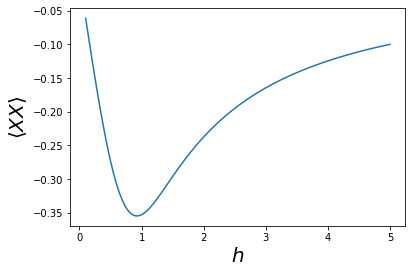

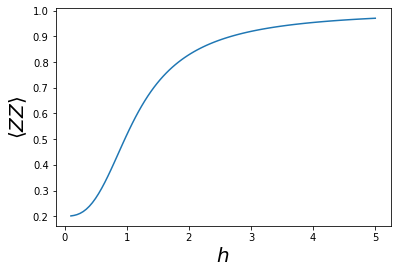

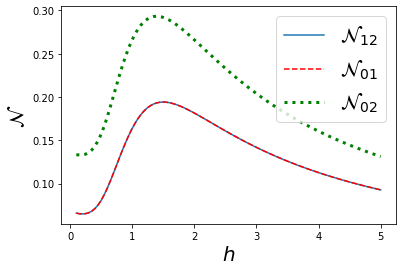

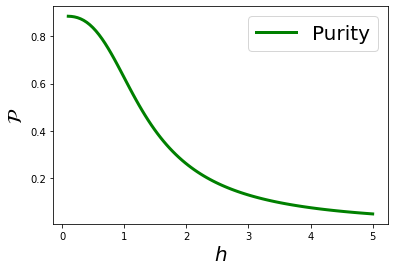

In [7]:
import matplotlib.pyplot as plt

plt.plot(h_grid[0:len(xx_vs_h)],xx_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle XX\rangle$',fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],zz_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle ZZ\rangle$',fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],neg12,label=r'$\mathcal{N}_{12}$')
plt.plot(h_grid[0:len(xx_vs_h)],neg01,label=r'$\mathcal{N}_{01}$',linestyle='--',color='red')
plt.plot(h_grid[0:len(xx_vs_h)],neg02,label=r'$\mathcal{N}_{02}$',linestyle=':',linewidth=3,color='green')

plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{N}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],purity,label=r'Purity',linewidth=3,color='green')
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{P}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()